# Biosignal Analysis with FMA data

In this project, we now have two sets of data that need to be combined to achieve the best possible solution.

In measurement tests, the BIOPAC BioNomadix Wireless device has been used to collect physiological data with different music genres. In this file, all  data collected from the test sessions has been analyzed and ultimately used to create a final 3-level dataset.

All levels explained:

Level 1: Raw signal data

Level 2: Segment-level feature dataset

Level 3: Session-level summary dataset

In [232]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
import sys
import bioread
import os
from datetime import datetime
from scipy.signal import butter, filtfilt
import neurokit2 as nk

## Level 1: Data Analysis

This level contains all the raw data located in the BIOPAC_DATA directory. All test subjects and their sessions are labeled as follows:

<code>subject_X_session_Y.csv</code>

X = test subject ID

Y = session number

In [233]:
# Open Signal from BIOPAC file
def read_biopac_data(file_path, channel_index=0):
    # Read the BIOPAC file
    data = bioread.read_file(file_path)
    # Extract the signal names and data
    fs = data.channels[channel_index].samples_per_second  # Sampling frequency
    sig = data.channels[channel_index].data  # Signal
    iso_time = data.earliest_marker_created_at  # Time of the first sample
    return sig, fs, iso_time

In [234]:
# Load time segments of measurements
def load_time_segments(file_path):
    df = pandas.read_csv(file_path)
    return df

In [235]:
subject_1_segments = load_time_segments('../data/raw/1_session_1.csv')

In [236]:
subject_1_segments.head()

,timestamp_ISO,timestamp_epoch,subject_id,session_id,block_id,event_type,genre,track_name
0,2026-03-03T13:52:47.944133,1.772539e+09,1,1,NaN,session_start,NaN,NaN
1,2026-03-03T13:52:47.944133,1.772539e+09,1,1,1.0,baseline_start,NaN,NaN
2,2026-03-03T13:53:47.945957,1.772539e+09,1,1,1.0,baseline_end,NaN,NaN
3,2026-03-03T13:53:47.947952,1.772539e+09,1,1,2.0,track_start,Experimental,116464.mp3
4,2026-03-03T13:54:18.055319,1.772539e+09,1,1,2.0,track_end,Experimental,116464.mp3


In [237]:
ecg_signal, fs, iso_time = read_biopac_data('BIOPAC_DATA/subject_1_test.gtl.acq', channel_index=3)

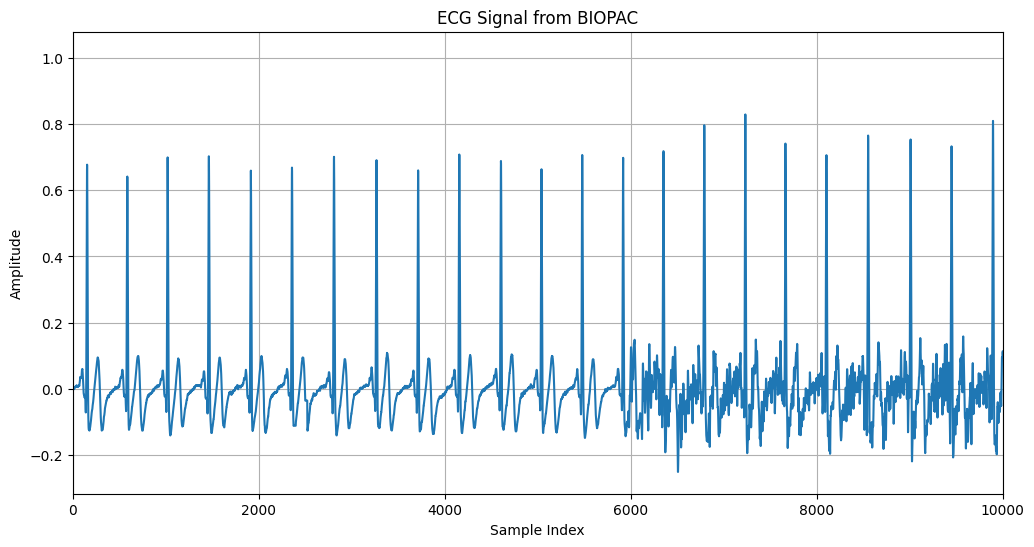

In [238]:
# Plot the ECG signal
plt.figure(figsize=(12, 6))
plt.plot(ecg_signal)
plt.title('ECG Signal from BIOPAC')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.xlim(0, 10000)
plt.grid()
plt.show()

In [239]:
# Iterate through all files in the BIOPAC_DATA directory and read all channels
data_dir = 'BIOPAC_DATA'
for filename in os.listdir(data_dir):
    if filename.endswith('.acq'):
        file_path = os.path.join(data_dir, filename)
        data = bioread.read_file(file_path)
        print(f"File: {filename}")
        for i, channel in enumerate(data.channels):
            print(f"  Channel {i}: {channel.name}, Sampling Rate: {channel.samples_per_second} Hz")

File: subject_1_test.gtl.acq
  Channel 0: PPG, X, PPGED-R, Sampling Rate: 500.0 Hz
  Channel 1: RSP, X, RSPEC-R, Sampling Rate: 500.0 Hz
  Channel 2: EDA, Y, PPGED-R, Sampling Rate: 500.0 Hz
  Channel 3: ECG, Y, RSPEC-R, Sampling Rate: 500.0 Hz
File: subject_2_test.gtl.acq
  Channel 0: PPG, X, PPGED-R, Sampling Rate: 500.0 Hz
  Channel 1: RSP, X, RSPEC-R, Sampling Rate: 500.0 Hz
  Channel 2: EDA, Y, PPGED-R, Sampling Rate: 500.0 Hz
  Channel 3: ECG, Y, RSPEC-R, Sampling Rate: 500.0 Hz


Recording Start Time (Epoch): 1772538767.944133


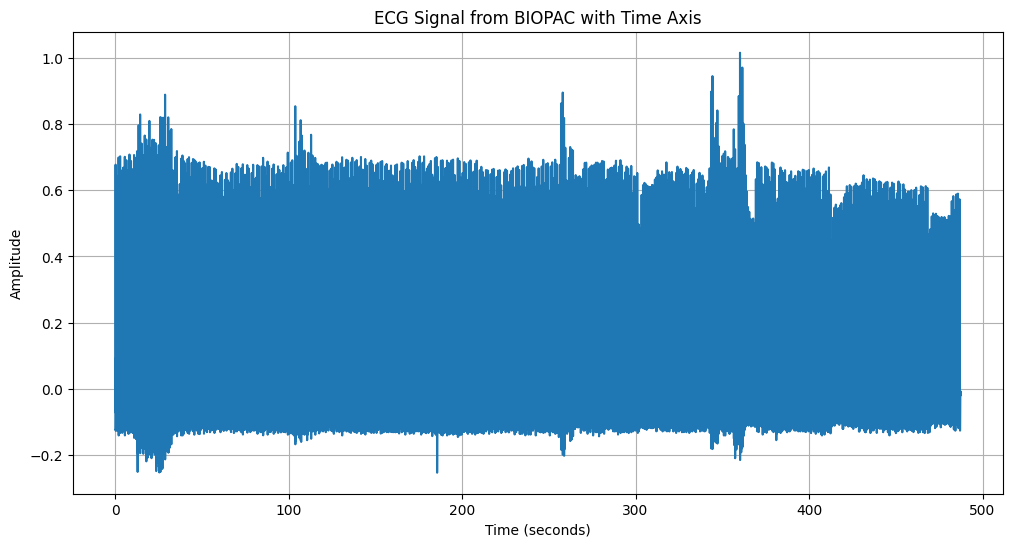

In [240]:
recording_start_time = subject_1_segments[subject_1_segments['event_type'] == 'session_start']['timestamp_epoch'].values[0]

print(f"Recording Start Time (Epoch): {recording_start_time}")

# Now plot the ECG signal with time on the x-axis
time_vector = np.arange(len(ecg_signal)) / fs  # Time in seconds
plt.figure(figsize=(12, 6))
plt.plot(time_vector, ecg_signal)
plt.title('ECG Signal from BIOPAC with Time Axis')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

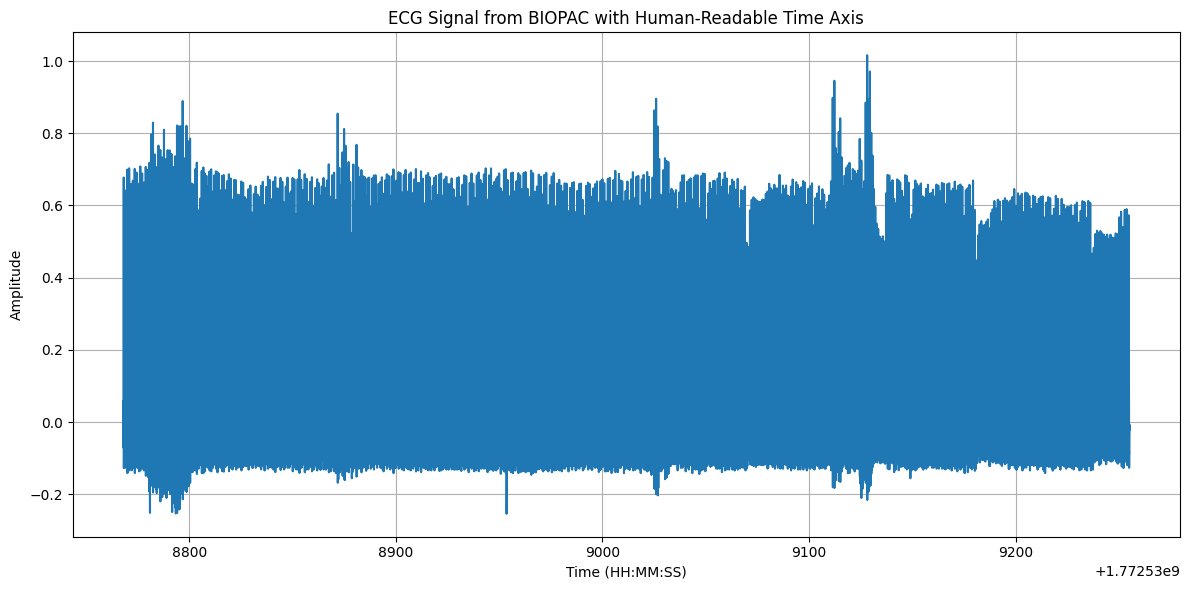

In [241]:
# Define the zero point of time as the recording start time
time_vector = time_vector + recording_start_time  # Shift time vector to align with recording start time
# Convert epoch time to human-readable format for x-axis labels
time_labels = [datetime.fromtimestamp(t).strftime('%H:%M:%S') for t in time_vector[::1000]]  # Label every 1000th point
plt.figure(figsize=(12, 6))
plt.plot(time_vector, ecg_signal)
plt.title('ECG Signal from BIOPAC with Human-Readable Time Axis')
plt.xlabel('Time (HH:MM:SS)')
plt.ylabel('Amplitude')
plt.grid()
plt.tight_layout()
plt.show()

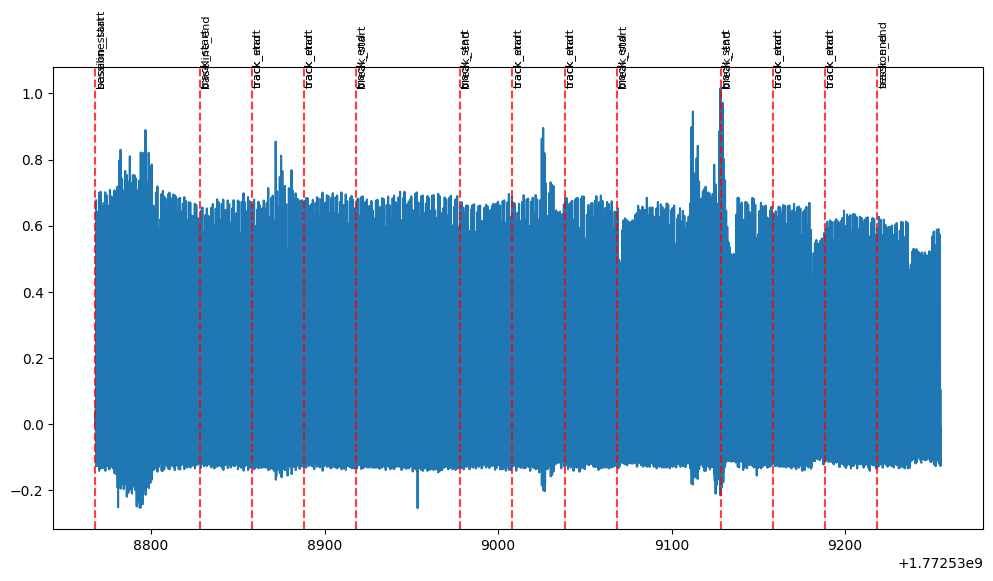

In [242]:
# Now draw vertical lines for ECG data by event types from the segments file
plt.figure(figsize=(12, 6))
plt.plot(time_vector, ecg_signal, label='ECG Signal')
for _, row in subject_1_segments.iterrows():
    event_time = row['timestamp_epoch']
    event_type = row['event_type']
    plt.axvline(x=event_time, color='red', linestyle='--', alpha=0.5)
    plt.text(event_time, max(ecg_signal), event_type, rotation=90, verticalalignment='bottom', fontsize=8)

In [243]:
# Use NeuroKit2 to clean the ECG signal and extract heart rate
signals, info = nk.ecg_process(ecg_signal, sampling_rate=fs)

cleaned_ecg = signals['ECG_Clean']
heart_rate = signals['ECG_Rate']
rpeaks_all = info['ECG_R_Peaks']

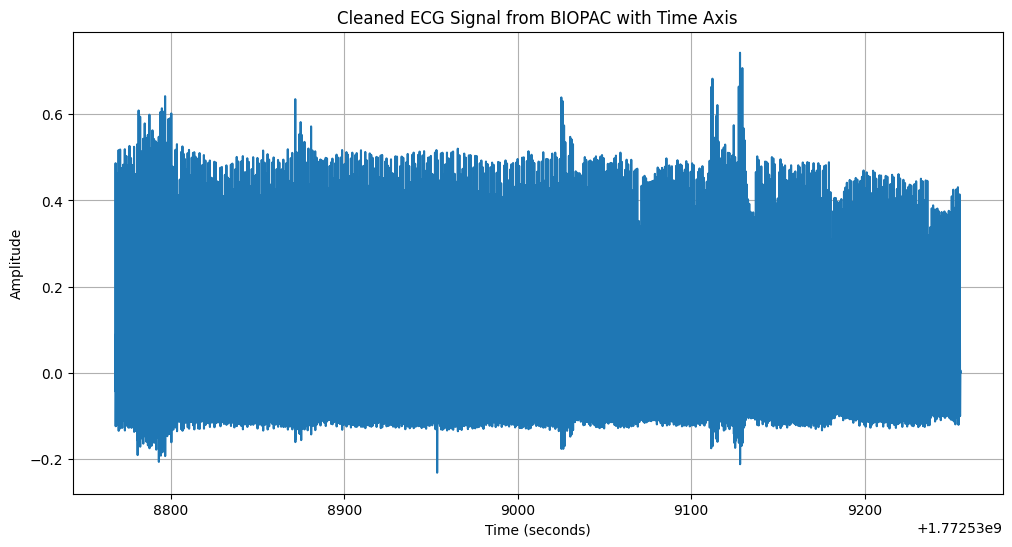

In [244]:
recording_start_time = subject_1_segments[subject_1_segments['event_type'] == 'session_start']['timestamp_epoch'].values[0]
time_vector = np.arange(len(cleaned_ecg)) / fs + recording_start_time  # Shift time vector to align with recording start time
plt.figure(figsize=(12, 6))
plt.plot(time_vector, cleaned_ecg, label='Cleaned ECG Signal')
plt.title('Cleaned ECG Signal from BIOPAC with Time Axis')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

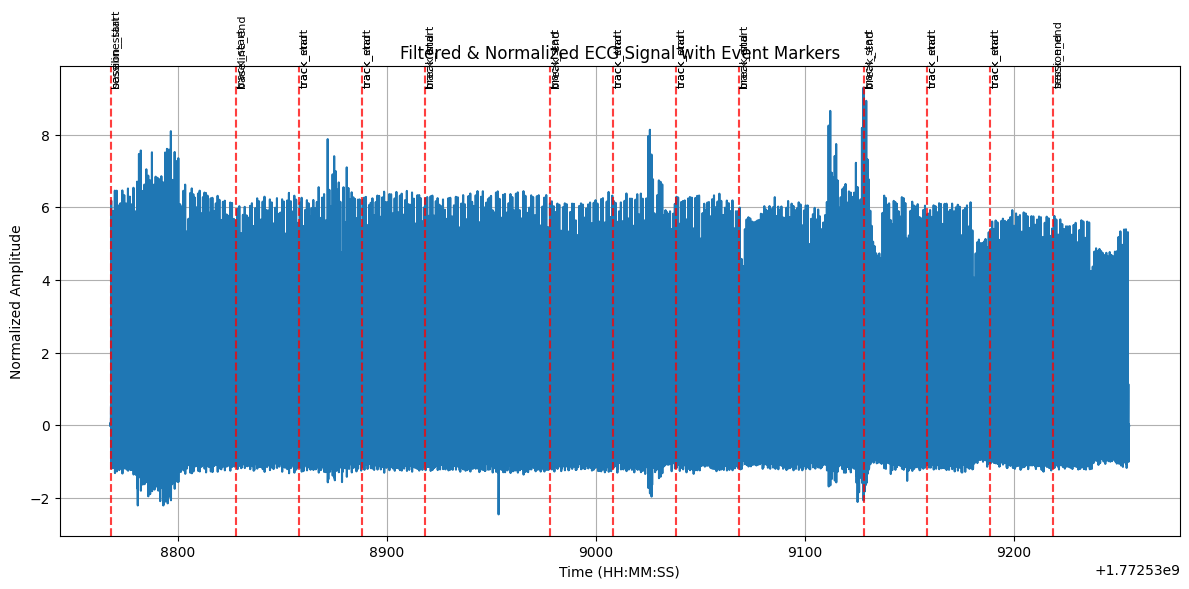

In [245]:
# Now filter and normalize the ECG signal for better visualization
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

b, a = butter_bandpass(0.5, 40, fs, order=4)
filtered_ecg = filtfilt(b, a, ecg_signal)
normalized_ecg = (filtered_ecg - np.mean(filtered_ecg)) / np.std(filtered_ecg)
plt.figure(figsize=(12, 6))
plt.plot(time_vector, normalized_ecg, label='Filtered & Normalized ECG Signal')
for _, row in subject_1_segments.iterrows():
    event_time = row['timestamp_epoch']
    event_type = row['event_type']
    plt.axvline(x=event_time, color='red', linestyle='--', alpha=0.5)
    plt.text(event_time, max(normalized_ecg), event_type, rotation=90, verticalalignment='bottom', fontsize=8)
plt.title('Filtered & Normalized ECG Signal with Event Markers')
plt.xlabel('Time (HH:MM:SS)')
plt.ylabel('Normalized Amplitude')
plt.grid()
plt.tight_layout()
plt.show()

In [246]:
# Define all the block segments based on the segment file
hrv_metrics = []

blocks = subject_1_segments['block_id'].dropna().unique()

for block in blocks:

    block_rows = subject_1_segments[subject_1_segments['block_id'] == block]
    block_start_time = block_rows['timestamp_epoch'].min()
    block_end_time = block_rows['timestamp_epoch'].max()

    start_relative = block_start_time - recording_start_time
    end_relative = block_end_time - recording_start_time

    start_sample = int(start_relative * fs)
    end_sample = int(end_relative * fs)

    block_rpeaks = rpeaks_all[(rpeaks_all >= start_sample) & (rpeaks_all < end_sample)]

    if len(block_rpeaks) > 3:
        hrv = nk.hrv_time(block_rpeaks, sampling_rate=fs)
        hrv['block_id'] = block
        hrv_metrics.append(hrv)

hrv_metrics_df = pandas.concat(hrv_metrics, ignore_index=True)

# Define the most imporant HRV metrics to analyze
important_metrics = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50']

hrv_important_df = hrv_metrics_df[important_metrics + ['block_id']]

hrv_important_df

,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_pNN50,block_id
0,850.314286,56.890065,23.291474,2.857143,1.0
1,818.256881,45.302359,22.985503,3.669725,2.0
2,862.647059,42.495922,21.261696,0.000000,3.0
3,839.813084,56.082508,24.947492,4.672897,4.0
4,811.315068,51.305424,25.497277,8.219178,5.0
5,838.897196,73.650492,23.538808,3.738318,6.0
